# 02. EDA and Degradation Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

columns = ["engine_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]
df_train = pd.read_csv("../data/train_FD001.txt", sep="\s+", header=None, names=columns)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gajen\AppData\Local\Temp\ipykernel_7884\3835827214.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv("../data/train_FD001.txt", sep="\s+", header=None, names=columns)


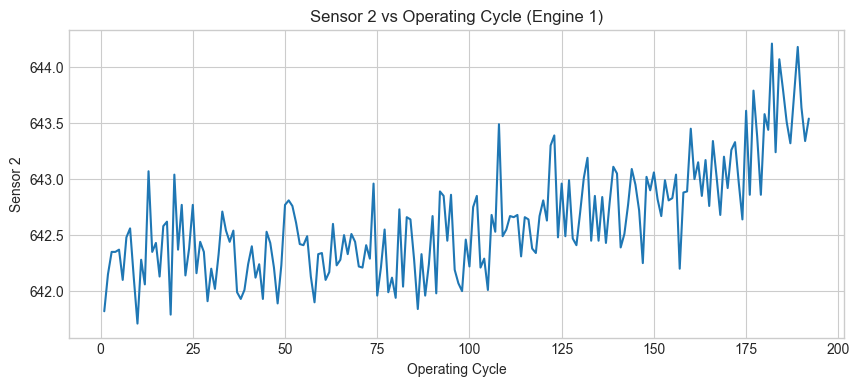

In [2]:
engine_1 = df_train[df_train["engine_id"] == 1]
plt.figure(figsize=(10, 4))
plt.plot(engine_1["cycle"], engine_1["sensor_2"])
plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 vs Operating Cycle (Engine 1)")
plt.savefig("../figures/sensor_degradation.png", bbox_inches="tight")
plt.show()

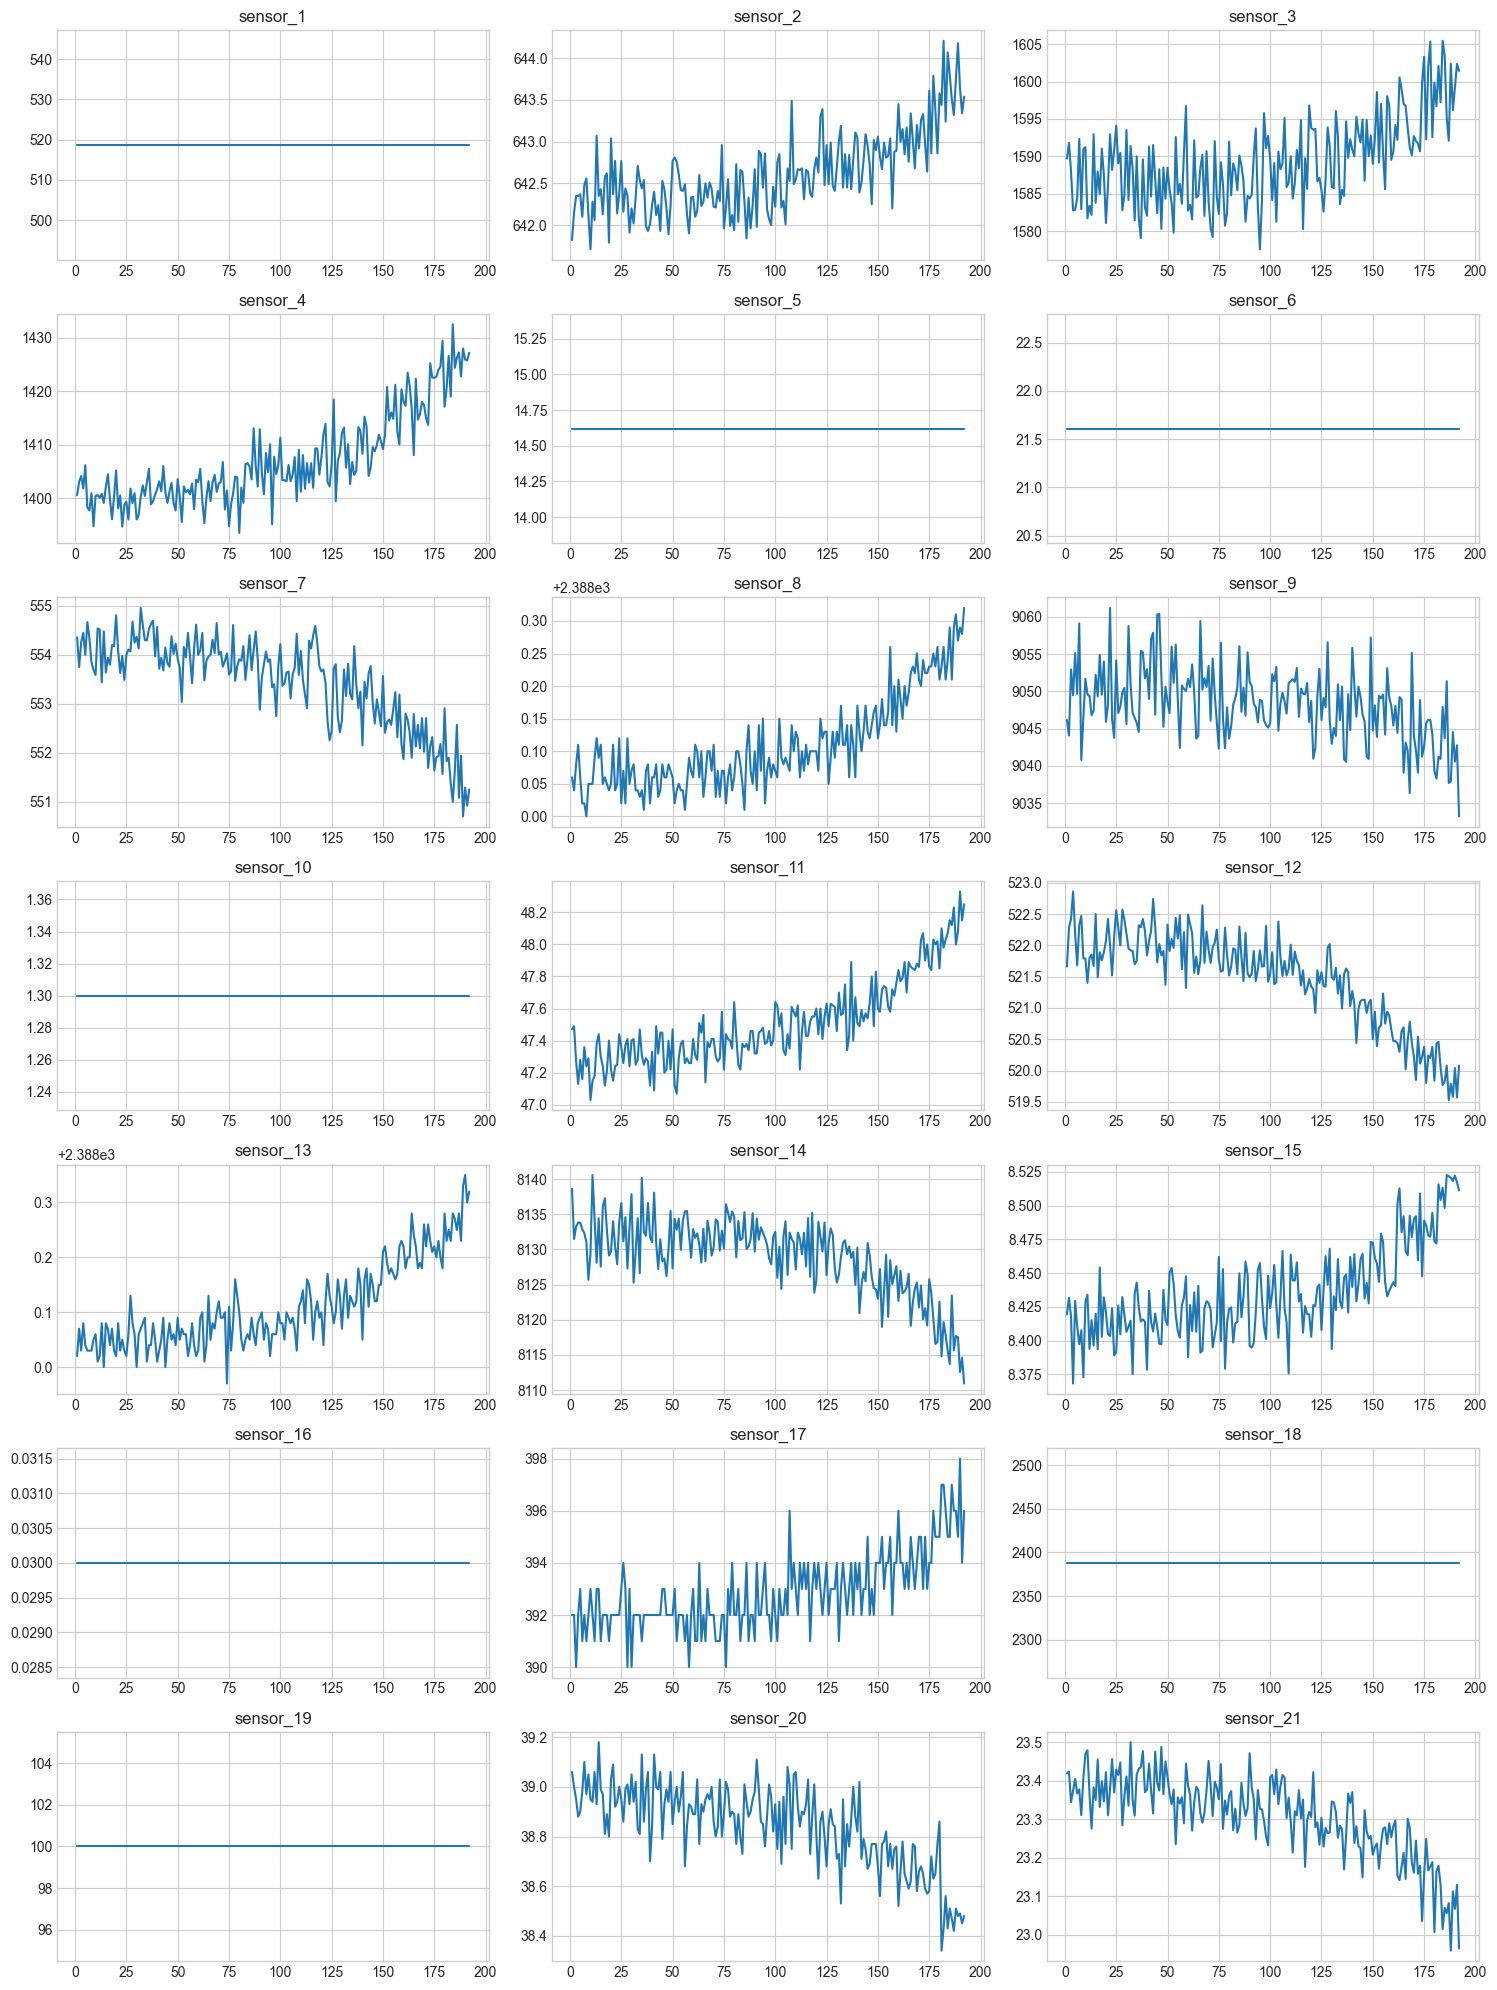

In [3]:
fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()
sensors = [f"sensor_{i}" for i in range(1, 22)]
for i, sensor in enumerate(sensors):
    axes[i].plot(engine_1["cycle"], engine_1[sensor])
    axes[i].set_title(sensor)
plt.tight_layout()
plt.show()

In [4]:
variances = df_train.var(numeric_only=True)
useless_sensors = [col for col in df_train.columns if df_train[col].var() < 1e-10]
print(f"Sensors to remove: {useless_sensors}")

Sensors to remove: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
